In [65]:
%load_ext autoreload
%autoreload 2
%xmode verbose

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Exception reporting mode: Verbose


In [66]:
# from ExoRM.get_data import get_data
# get_data()

# from ExoRM.initialize_model import initialize_model
# initialize_model()

# Use these to initialize / update the model

In [67]:
from ExoRM import read_rm_data, load_model, ForecasterRM, preprocess_data, read_exoplanet_data

import numpy
import matplotlib.pyplot as plot
import matplotlib
import pandas
import seaborn
import math
import time

save = False # save the figures / csv to files
plot.style.use('seaborn-v0_8-paper')
seaborn.set_theme(style = 'white', context = 'paper')
matplotlib.rcParams['figure.figsize'] = [4, 3]
matplotlib.rcParams['axes.labelsize'] = 10  # Axis label font size
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['figure.dpi'] = 300
matplotlib.rcParams['figure.constrained_layout.use'] = True

matplotlib.rcParams['lines.markersize'] = 1.2  # Default marker size (scatter size)
matplotlib.rcParams['lines.linewidth'] = 2   # Default line width

path = 'Paper Material/ExoRM'

data = read_rm_data()
data = preprocess_data(data)
data = data[['name', 'radius', 'mass', 'density']]

data

,name,radius,mass,density
0,2MASS J02192210-3925225 b,16.140960,4417.837000,1.050562
1,55 Cnc e,1.875000,7.990000,1.212113
2,BD-14 3065 b,21.590000,3932.000000,0.390711
3,CFHTWIR-Oph 98 b,20.848704,2479.061575,0.273558
4,CoRoT-1 b,19.223435,390.930900,0.055031
...,...,...,...,...
959,XO-3 b,13.988832,3759.928900,1.373521
960,XO-4 b,15.020060,512.341960,0.151198
961,XO-5 b,12.780000,378.200000,0.181188
962,XO-7 b,15.356304,225.658169,0.062315


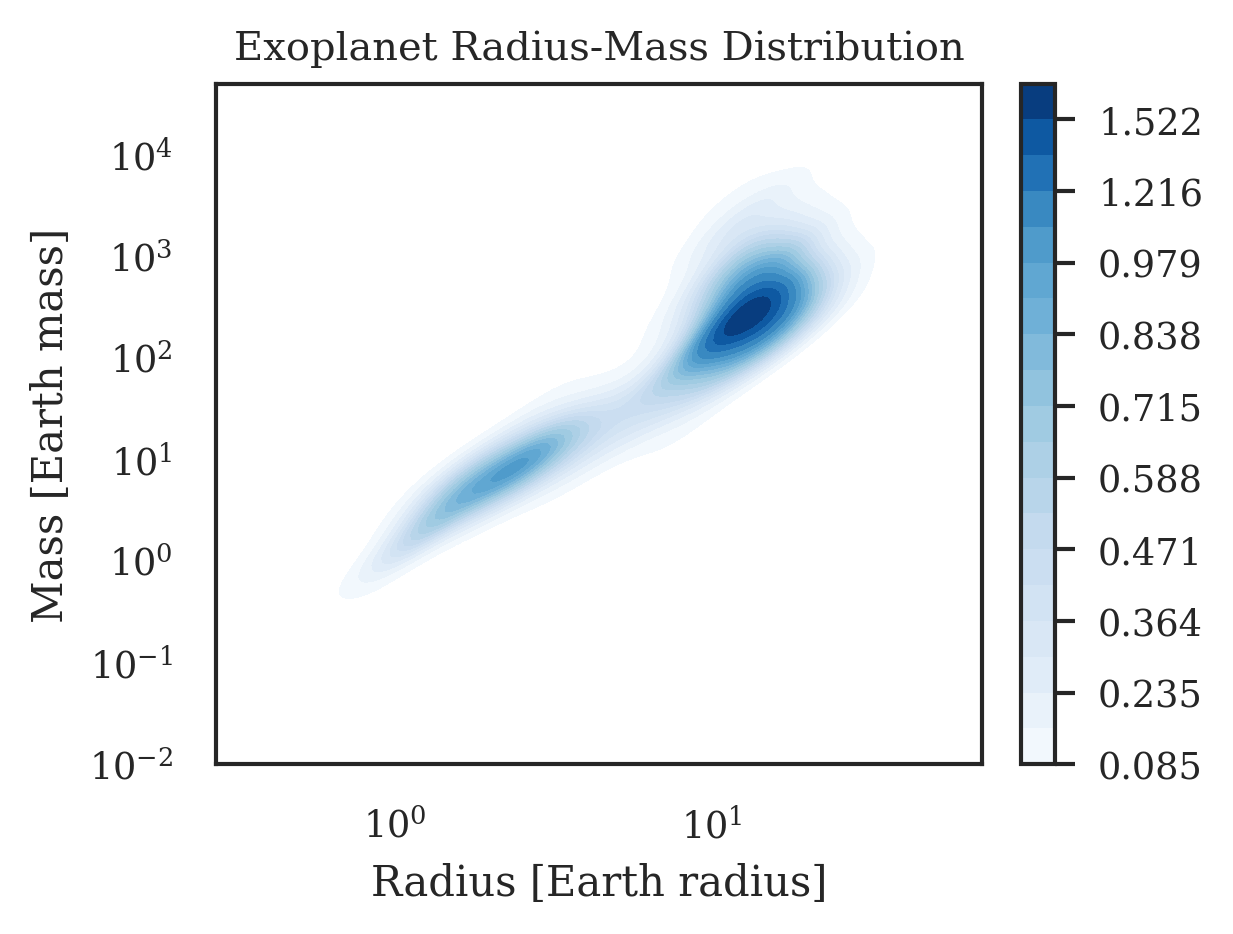

In [68]:
columns = ['radius', 'mass']

x = data['radius']
y = data['mass']

x = numpy.log10(x)
y = numpy.log10(y)
ax = seaborn.kdeplot(data, x = 'radius', y = 'mass', fill = True, cmap = 'Blues', levels = 20, cbar = True, log_scale = True)
# seaborn.scatterplot(numpy.log10(data[columns]), x = 'radius', y = 'mass', s = 5, color = 'black', zorder = 2)
# plot.gca().set_aspect('auto')

# plot.xlim(-0.3, 1.6)
# plot.ylim(-0.75, 4.25)

plot.xlabel('Radius [Earth radius]')
plot.ylabel('Mass [Earth mass]')
plot.title('Exoplanet Radius-Mass Distribution')

# if save: plot.savefig(f'{path}/Figure 1.jpeg')

plot.show()

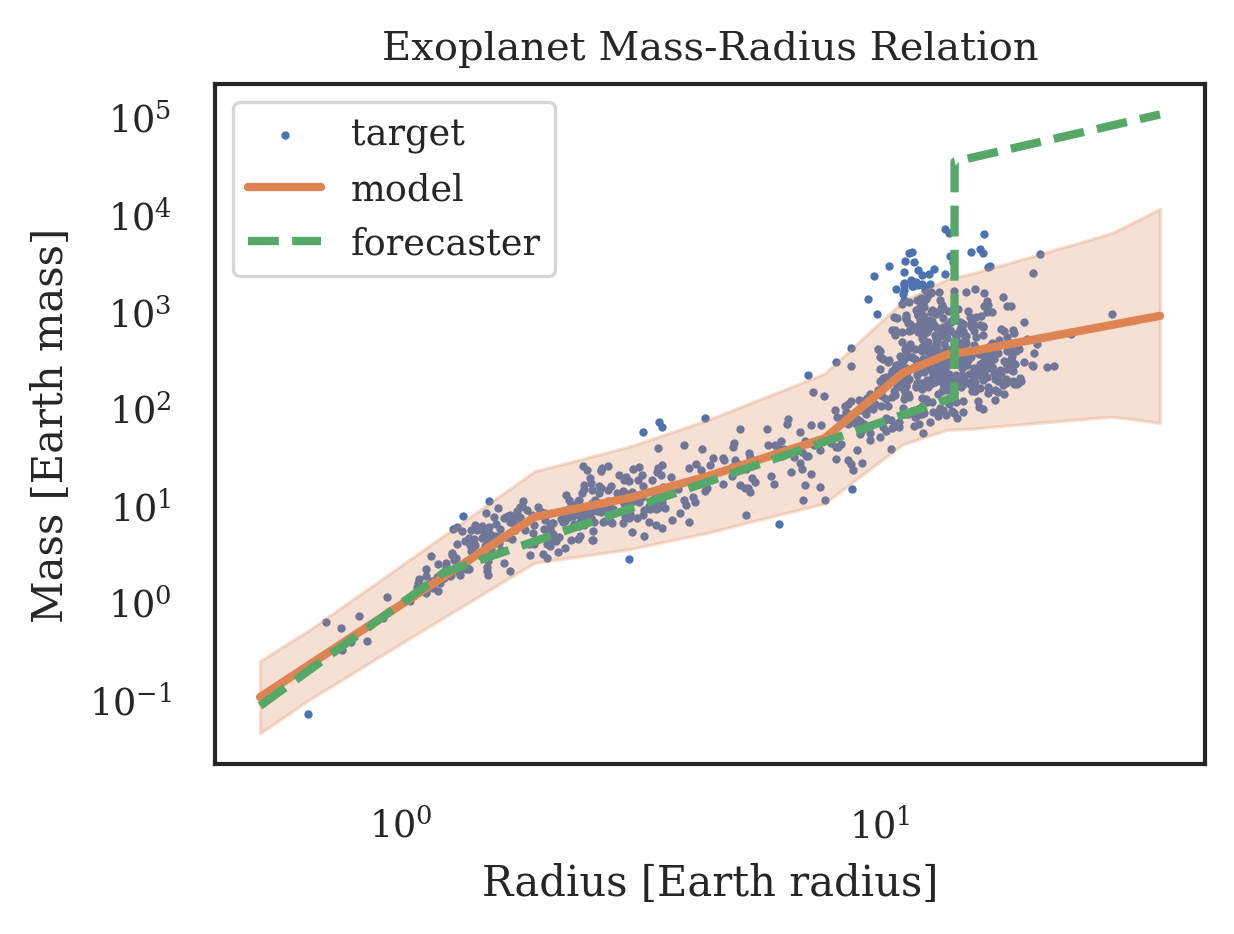

In [69]:
model = load_model()

xs = numpy.linspace(x.min() - 0.1, x.max() + 0.1, 10000)

ms = model(xs)
ms_e = model.error(xs)
ms2 = ForecasterRM.forecaster(xs)

plot.scatter(10 ** x, 10 ** y)
plot.plot(10 ** xs, 10 ** ms, color = 'C1')
plot.plot(10 ** xs, 10 ** ms2, '--', color = 'C2')

plot.fill_between(10 ** xs, 10 ** (ms - ms_e), 10 ** (ms + ms_e), color = 'C1', alpha = 0.25)

plot.legend(['target', 'model', 'forecaster'])
plot.xlabel('Radius [Earth radius]')
plot.ylabel('Mass [Earth mass]')
plot.title('Exoplanet Mass-Radius Relation')

plot.loglog()

if save: plot.savefig(f'{path}/Figure 2.jpeg')

plot.show()

In [70]:
m = model(x)
m_e = model.error(x)
out_error = len(x[(y < (m - m_e)) | (y > (m + m_e))])
out_error / len(x)

0.056016597510373446

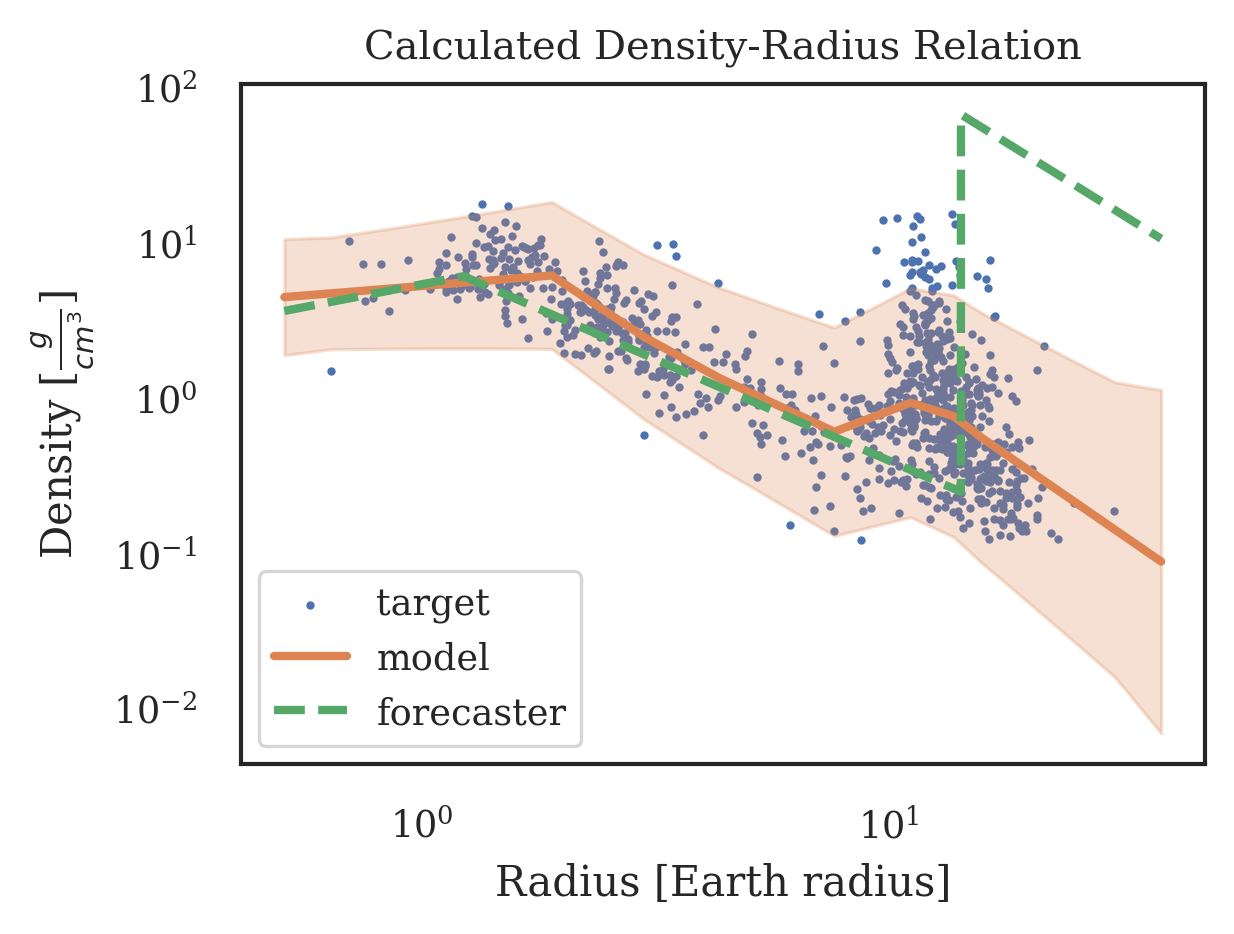

In [71]:
a = numpy.log10(5.51)  # Density of Earth in g / cm^3

plot.scatter(10 ** x, 10 ** ((y - 3 * x) + a))
ds = (ms - 3 * xs) + a
ds2 = (ms2 - 3 * xs) + a
plot.plot(10 ** xs, 10 ** ds, color = 'C1')
plot.plot(10 ** xs, 10 ** ds2, '--', color = 'C2')

plot.fill_between(10 ** xs,
                  10 ** (((ms - ms_e) - 3 * xs) + a),
                  10 ** (((ms + ms_e) - 3 * xs) + a),
                  color = 'C1', alpha = 0.25)

plot.legend(['target', 'model', 'forecaster'])
plot.xlabel('Radius [Earth radius]')
plot.ylabel('Density [${\\frac{g}{cm^3}}$]')
plot.title('Calculated Density-Radius Relation')

plot.loglog()

if save: plot.savefig(f'{path}/Figure 4.jpeg')

plot.show()

In [72]:
ms1ts = []
ms2ts = []

for i in range(100):
    start_time = time.time()
    model(xs)
    ms1t = time.time() - start_time

    start_time = time.time()
    ForecasterRM.forecaster(xs)
    ms2t = time.time() - start_time

    ms1ts.append(ms1t)
    ms2ts.append(ms2t)

ms1t = numpy.mean(ms1ts) * 1e3
ms2t = numpy.mean(ms2ts) * 1e3

print('ExoRM time (ms): ', ms1t)
print('Forecaster time (ms): ', ms2t)

ExoRM time (ms):  0.10796785354614258
Forecaster time (ms):  0.08735895156860352


In [73]:
p_data = data.copy()
columns = ['radius', 'mass']
p_data[columns] = numpy.log10(p_data[columns])

p_data

,name,radius,mass,density
0,2MASS J02192210-3925225 b,1.207929,3.645210,1.050562
1,55 Cnc e,0.273001,0.902547,1.212113
2,BD-14 3065 b,1.334253,3.594614,0.390711
3,CFHTWIR-Oph 98 b,1.319079,3.394287,0.273558
4,CoRoT-1 b,1.283831,2.592100,0.055031
...,...,...,...,...
959,XO-3 b,1.145781,3.575180,1.373521
960,XO-4 b,1.176672,2.709560,0.151198
961,XO-5 b,1.106531,2.577722,0.181188
962,XO-7 b,1.186287,2.353451,0.062315


In [74]:
p_data['ExoRM'] = model(p_data['radius'])
p_data['Forecaster'] = ForecasterRM.forecaster(p_data['radius'])

p_data['ExoRM res'] = (p_data['mass'] - p_data['ExoRM'])
p_data['Forecaster res'] = (p_data['mass'] - p_data['Forecaster'])

p_data['name_len'] = p_data['name'].str.len()
p_data = p_data.sort_values(
    by = ['name_len', 'name'],
).reset_index(drop = True)
p_data = p_data.drop(columns = ['name_len'])

columns = ['radius', 'mass', 'ExoRM', 'Forecaster', 'ExoRM res', 'Forecaster res']

p_data[columns] = p_data[columns].map(
    lambda x: x if x == 0 or math.isnan(x) else round(x, (5 - 1) - int(math.floor(math.log10(abs(x)))))
)

p_data['winner'] = p_data.apply(
    lambda x: 'ExoRM' if abs(x['ExoRM res']) < abs(x['Forecaster res']) else 'Forecaster', axis = 1
)

if save: p_data[['name'] + columns + ['winner']].to_csv(f'{path}/ExoRM_results.csv', index = False)

p_data.head(10)

,name,radius,mass,density,ExoRM,Forecaster,ExoRM res,Forecaster res,winner
0,PH2 b,0.97021,1.93990,0.106982,2.04830,1.80430,-0.108350,0.135680,ExoRM
1,K2-3 b,0.31765,0.70842,0.569488,0.91975,0.69634,-0.211330,0.012079,Forecaster
2,K2-3 d,0.18469,1.04530,3.099193,0.57587,0.47061,0.469450,0.574710,ExoRM
3,XO-1 b,1.13090,2.46270,0.117469,2.54010,2.07710,-0.077482,0.385560,ExoRM
4,XO-3 b,1.14580,3.57520,1.373521,2.56200,2.10230,1.013200,1.472800,ExoRM
5,XO-4 b,1.17670,2.70960,0.151198,2.58270,4.57060,0.126820,-1.861000,ExoRM
6,XO-5 b,1.10650,2.57770,0.181188,2.48990,2.03570,0.087804,0.542020,ExoRM
7,XO-7 b,1.18630,2.35350,0.062315,2.58920,4.58150,-0.235740,-2.228000,ExoRM
8,GPX-1 b,1.21690,3.79670,1.399615,2.61520,4.61620,1.181500,-0.819550,Forecaster
9,K2-18 b,0.41664,0.93601,0.485388,1.01840,0.86442,-0.082360,0.071596,Forecaster


In [75]:
p_data['Percent ExoRM err'] = 100 * ((10 ** p_data['ExoRM res']) / (10 ** p_data['mass']))
p_data['Percent Forecaster err'] = 100 * ((10 ** p_data['Forecaster res']) / (10 ** p_data['mass']))

p_data[['Percent ExoRM err', 'Percent Forecaster err', 'ExoRM res', 'Forecaster res']].abs().describe()

,Percent ExoRM err,Percent Forecaster err,ExoRM res,Forecaster res
count,964.000000,964.000000,964.000000,964.000000
mean,8.791172,10.413695,0.250444,0.721964
std,28.020505,30.170486,0.230438,0.761550
min,0.137016,0.001204,0.000009,0.000195
25%,0.276858,0.809841,0.076757,0.147718
50%,0.429324,1.161556,0.189135,0.369085
75%,8.371625,10.847971,0.355413,1.102975
max,448.766056,509.436432,1.296100,2.651700


In [76]:
from scipy.stats import ttest_rel
stat, val = ttest_rel(p_data['Percent ExoRM err'], p_data['Percent Forecaster err'])
stat, val

(np.float64(-13.89983917049128), np.float64(3.639079413663854e-40))

In [77]:
from scipy.stats import wilcoxon
stat, val = wilcoxon(p_data['Percent ExoRM err'], p_data['Percent Forecaster err'])
stat, val

(np.float64(49576.0), np.float64(2.1271609717988263e-99))

In [78]:
p_data['winner'].value_counts() / len(p_data)

winner
ExoRM         0.754149
Forecaster    0.245851
Name: count, dtype: float64

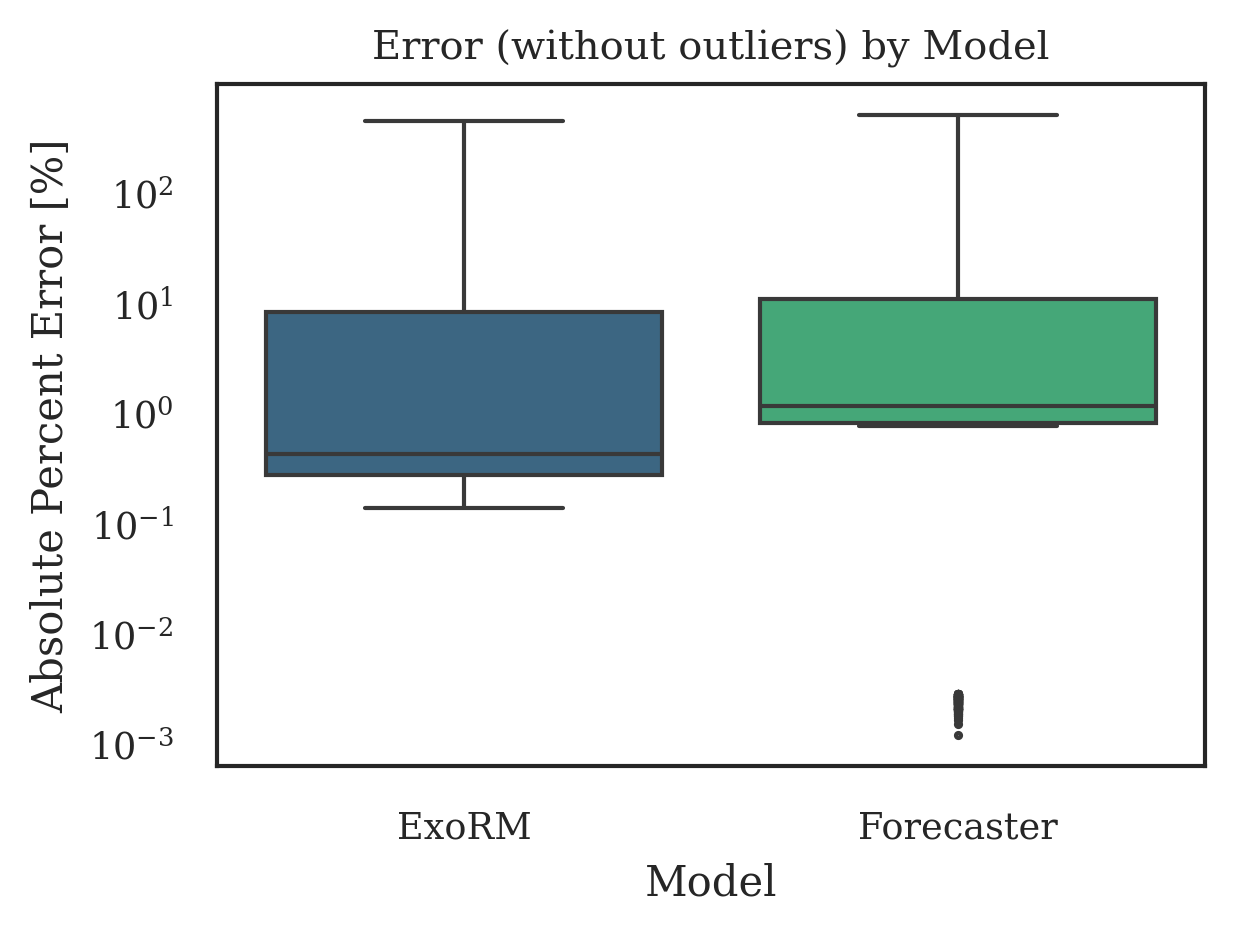

,Model,Absolute Percent Error [%]
0,ExoRM,0.894850
1,ExoRM,12.029567
2,ExoRM,26.555226
3,ExoRM,0.288282
4,ExoRM,0.274157
...,...,...
1923,Forecaster,16.544742
1924,Forecaster,22.414549
1925,Forecaster,7.661221
1926,Forecaster,6.791567


In [79]:
p_data_long = pandas.melt(
    p_data,
    value_vars = ['Percent ExoRM err', 'Percent Forecaster err'],
    var_name = 'Model',
    value_name = 'Absolute Percent Error [%]'
)

p_data_long['Model'] = p_data_long['Model'].map(lambda x: 'ExoRM' if x == 'Percent ExoRM err' else 'Forecaster')

ax = seaborn.boxplot(data = p_data_long, x = 'Model', y = 'Absolute Percent Error [%]', hue = 'Model', palette = 'viridis', zorder = 1, whis = 1.5, showfliers = True, log_scale = True)
# ax.set_yscale('log')
plot.title('Error (without outliers) by Model')

if save: plot.savefig(f'{path}/Figure 3.jpeg')

plot.show()

p_data_long

In [80]:
10 ** xs[numpy.argmin(numpy.abs((10 ** ms) - 317.9 * 13))]
# the deuterium burning limit radius

np.float64(38.38272223897823)

In [81]:
numpy.mean(numpy.abs(ms - ms2))
# average change metween two models

np.float64(0.5613178828168776)

In [82]:
10 ** xs[numpy.argmin(ds)], 10 ** xs[numpy.argmax(ds)], 10 ** xs[numpy.argmin(ds2)], 10 ** xs[numpy.argmax(ds2)]
# min and max density points for both models

(np.float64(38.38272223897823),
 np.float64(1.8994949680443753),
 np.float64(14.294460597116995),
 np.float64(14.300643695671999))

In [83]:
10 ** min(ds), 10 ** max(ds), 10 ** min(ds2), 10 ** max(ds2)
# min and max density values for both models

(np.float64(0.08806569233410041),
 np.float64(6.107624082282664),
 np.float64(0.24770212340646683),
 np.float64(66.2916677251605))

In [84]:
exoplanet_data = read_exoplanet_data()

exoplanet_data[['name', 'radius', 'mass', 'year']] = exoplanet_data[['pl_name', 'pl_rade', 'pl_bmasse', 'disc_year']]
exoplanet_data = exoplanet_data[exoplanet_data['pl_controv_flag'] == 0]
exoplanet_data = exoplanet_data.drop(columns = ['pl_controv_flag', 'pl_name', 'pl_rade', 'pl_bmasse', 'disc_year'])
exoplanet_data = exoplanet_data[exoplanet_data['radius'].notna() & exoplanet_data['mass'].notna()]
exoplanet_data[['radius', 'mass']] = numpy.log10(exoplanet_data[['radius', 'mass']])

old_exoplanet_data = exoplanet_data[exoplanet_data['year'] < 2017].copy()
new_exoplanet_data = exoplanet_data[exoplanet_data['year'] >= 2017].copy()

new_exoplanet_data = new_exoplanet_data.sort_values(by = ['name', 'year'], ascending = [True, False]).drop_duplicates(subset = 'name').reset_index(drop = True)
old_exoplanet_data = old_exoplanet_data.sort_values(by = ['name', 'year'], ascending = [True, False]).drop_duplicates(subset = 'name').reset_index(drop = True)
new_exoplanet_data, old_exoplanet_data

(     pl_bmasseerr1  pl_bmasseerr2  pl_radeerr1  pl_radeerr2  \
 0       290.000000    -280.000000     1.050000    -1.050000   
 1       222.479885    -254.262726     0.560449    -0.560449   
 2        69.922600     -69.922600     0.851884    -0.851884   
 3       117.596511    -117.596511     1.232988    -1.232988   
 4         0.750000      -0.750000     0.079000    -0.079000   
 ..             ...            ...          ...          ...   
 559       0.460000      -0.460000     0.060000    -0.060000   
 560       0.690000      -0.700000     0.069000    -0.069000   
 561      10.806220     -10.806220     0.291434    -0.291434   
 562     317.828407    -317.828407     0.212971    -0.212971   
 563       0.840000      -0.860000     0.050000    -0.050000   
 
                  soltype              name    radius      mass  year  
 0    Published Confirmed      BD-14 3065 b  1.334253  3.594614  2024  
 1    Published Confirmed  CFHTWIR-Oph 98 b  1.319079  3.394287  2021  
 2    Publishe

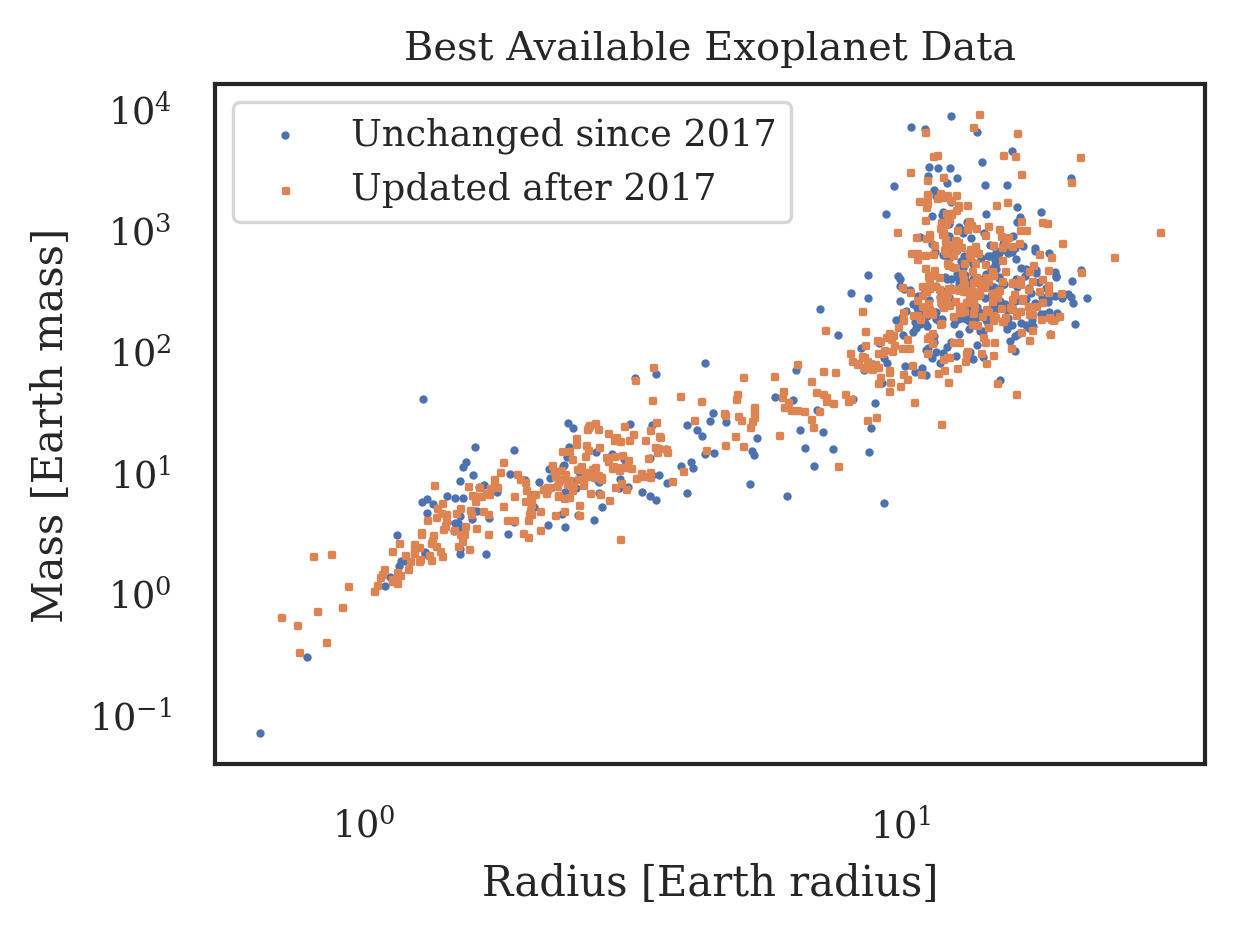

In [85]:
plot.scatter(10 ** old_exoplanet_data['radius'], 10 ** old_exoplanet_data['mass'], marker = 'o')
plot.scatter(10 ** new_exoplanet_data['radius'], 10 ** new_exoplanet_data['mass'], marker = 's')
plot.legend(['Unchanged since 2017', 'Updated after 2017'])

plot.xlabel('Radius [Earth radius]')
plot.ylabel('Mass [Earth mass]')
plot.title('Best Available Exoplanet Data')

plot.loglog()

if save: plot.savefig(f'{path}/Figure 1.jpeg')

plot.show()